In [1]:
# Import
import ee
import geemap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
from PIL import Image
from io import BytesIO
from IPython.display import display, HTML

def show_map(m):
    """Reliably display a geemap Map in Codespaces."""
    try:
        display(m)
    except Exception:
        display(HTML(m.to_html()))

print("✅ All imports successful!")

✅ All imports successful!


In [2]:
# Authenticate
ee.Authenticate()

True

In [3]:
# Initialize
PROJECT_ID = 'ee-xinranzhou2059'   # ⚠️ replace this

ee.Initialize(project=PROJECT_ID)
print(f"✅ Earth Engine initialized — project: {PROJECT_ID}")

✅ Earth Engine initialized — project: ee-xinranzhou2059


In [4]:
# Define the Study Area
lat_north = 40.7666667
lat_south = 39.4833333
lon_west = -105.4666667
lon_east = -105.05

study_area = ee.Geometry.Rectangle([lon_west, lat_south, lon_east, lat_north])

Map = geemap.Map(
    center=[(lat_north + lat_south) / 2, (lon_west + lon_east) / 2],
    zoom=9
)
Map.addLayer(study_area, {'color': 'red'}, 'Study Area Rectangle')
Map

Map(center=[40.125, -105.25833335], controls=(WidgetControl(options=['position', 'transparent_bg'], position='…

In [5]:
##### Map DEM elevation within the study area to verify the west-to-east mountain-to-plains gradient 
##### for elevation-based forest change analysis 
# Load DEM
dem = ee.Image('USGS/3DEP/10m').select('elevation').clip(study_area) # 在Google Earth Engine里加载10米分辨率的数字高程模型

# DEM visualization # 把1400–3000米之间的高程映射到颜色条上
dem_vis = {
    'min': 1400,
    'max': 3000,
    'palette': ['#f7fcf5', '#c7e9c0', '#74c476', '#238b45', '#00441b']
}

Map = geemap.Map(
    center=[(lat_north + lat_south) / 2, (lon_west + lon_east) / 2],
    zoom=9
) # 地图缩放级别为9
Map.addLayer(study_area, {'color': 'red'}, 'Study Area') # 添加研究区边界
Map.addLayer(dem, dem_vis, 'Elevation') # 添加 DEM 高程图层
Map.add_colorbar(dem_vis, label='Elevation (m)')
Map

Map(center=[40.125, -105.25833335], controls=(WidgetControl(options=['position', 'transparent_bg'], position='…

In [ ]:
## The elevation map shows a strong west-to-east gradient, with higher mountainous terrain in the west and lower urban/plains areas in the east, supporting elevation-based forest change analysis.

In [7]:
# Create low, middle, and high elevation bands for the study area

# Load DEM and clip to study area
dem = ee.Image('USGS/3DEP/10m').select('elevation').clip(study_area) # 获取 study area 内的高程图

# Check elevation statistics within the study area
elev_stats = dem.reduceRegion(
    reducer=ee.Reducer.minMax().combine(
        reducer2=ee.Reducer.mean(),
        sharedInputs=True
    ),# 计算最低、最高、平均海拔
    geometry=study_area,
    scale=30, # 用 30 米尺度进行统计
    maxPixels=1e9 # 允许 Earth Engine 处理最多很多像元，避免因为研究区较大时报像元数量超限
).getInfo()

print("Elevation statistics:", elev_stats)

Elevation statistics: {'elevation_max': 3275.802734375, 'elevation_mean': 2014.1831577144883, 'elevation_min': 1479.699951171875}


In [ ]:
# Elevation statistics: {'elevation_max': 3275.802734375, 'elevation_mean': 2014.183157714488, 'elevation_min': 1479.699951171875}

In [6]:
# Define low, middle, and high elevation bands based on observed DEM statistics
# Study area elevation ranges from ~1480 m to ~3276 m, with a mean around 2014 m.

elevation_bands = { # Python dictionary，用来记录高程分组规则
    'Low elevation': (1480, 1800),
    'Middle elevation': (1800, 2200),
    'High elevation': (2200, 3300)
}

low_band = dem.gte(1480).And(dem.lt(1800)).multiply(1) # 选出 DEM 中海拔 大于等于 1480 m 且小于 1800 m 的区域，把这个低海拔区域赋值为 1
mid_band = dem.gte(1800).And(dem.lt(2200)).multiply(2)# 中海拔：选出海拔 1800–2200 m 的区域，并赋值为 2
high_band = dem.gte(2200).And(dem.lte(3300)).multiply(3)#高海拔：选出海拔 2200–3300 m 的区域，并赋值为 3

elevation_class = low_band.max(mid_band).max(high_band).selfMask().rename('elevation_band') #把低、中、高三个高程带合并成一张分类图

In [7]:
# Visualize elevation bands to confirm that low, middle, and high zones align with the Front Range gradient

elev_band_vis = {
    'min': 1,
    'max': 3,
    'palette': ['#fee8c8', '#fdbb84', '#7f0000']
} # 定义了 elev_band_vis，也就是高程带图层的可视化参数

Map = geemap.Map(
    center=[(lat_north + lat_south) / 2, (lon_west + lon_east) / 2],
    zoom=9
) # 创建地图

Map.addLayer(study_area, {'color': 'red'}, 'Study Area') # 把study_area 红色矩形框加到地图上
Map.addLayer(elevation_class, elev_band_vis, 'Elevation Bands') # 把前面生成的 elevation_class 高程带分类图加到地图上
Map.add_colorbar(elev_band_vis, label='Elevation band') # 添加颜色条
Map

Map(center=[40.125, -105.25833335], controls=(WidgetControl(options=['position', 'transparent_bg'], position='…

In [ ]:
# Elevation bands align with the Front Range gradient: high elevations occur in the western mountains, while low elevations occur near the eastern urban/plains corridor.

In [8]:
# Load Annual NLCD land cover and calculate forest area by elevation band

annual_nlcd = ee.ImageCollection(
    'projects/sat-io/open-datasets/USGS/ANNUAL_NLCD/LANDCOVER'
) # 加载 Annual NLCD land cover 数据集

nlcd_2021 = (
    annual_nlcd
    .filter(ee.Filter.eq('year', 2021))
    .first()
    .clip(study_area)
) # 选择 2021 年 NLCD，并裁剪到研究区

forest_2021 = (
    nlcd_2021
    .remap([41, 42, 43], [1, 1, 1], 0)
    .rename('forest')
) # 提取森林类别

pixel_area_ha = ee.Image.pixelArea().divide(10000) # 创建像元面积图，单位转成 ha

def forest_area_by_band(band_name, low, high): # 输入一个高程带名称、下限和上限，输出这个高程带里的森林面积
    elev_mask = dem.gte(low).And(dem.lt(high)) # 创建高程 mask
    
    forest_area = ( # 计算森林面积
        forest_2021
        .eq(1)
        .And(elev_mask)
        .multiply(pixel_area_ha)
        .reduceRegion(
            reducer=ee.Reducer.sum(),
            geometry=study_area,
            scale=30,
            maxPixels=1e9
        )
        .get('forest')
    )
    
    return ee.Feature(None, {
        'elevation_band': band_name,
        'elev_low_m': low,
        'elev_high_m': high,
        'forest_area_ha': forest_area
    }) # 把结果包装成一个 Earth Engine Feature

forest_area_features = ee.FeatureCollection([
    forest_area_by_band('Low', 1480, 1800),
    forest_area_by_band('Middle', 1800, 2200),
    forest_area_by_band('High', 2200, 3300)
])

# Convert FeatureCollection to pandas DataFrame manually
features_info = forest_area_features.getInfo()['features'] # 把 Earth Engine 服务器端的 FeatureCollection 下载到 Python 本地

rows = []
for feature in features_info:
    rows.append(feature['properties']) # 把每个 Feature 的属性提取出来，放进 rows 列表。

forest_area_df = pd.DataFrame(rows) # 把这些结果转成 pandas DataFrame

forest_area_df

,elev_high_m,elev_low_m,elevation_band,forest_area_ha
0,1800,1480,Low,2851.566000
1,2200,1800,Middle,41252.445177
2,3300,2200,High,111559.856824


In [ ]:
# The 2021 NLCD results show that forest cover is strongly concentrated at higher elevations, with the high-elevation band containing the largest forest area, the middle-elevation band containing moderate forest area, and the low-elevation band containing very little forest. This pattern supports the use of elevation bands for analyzing Front Range forest change.

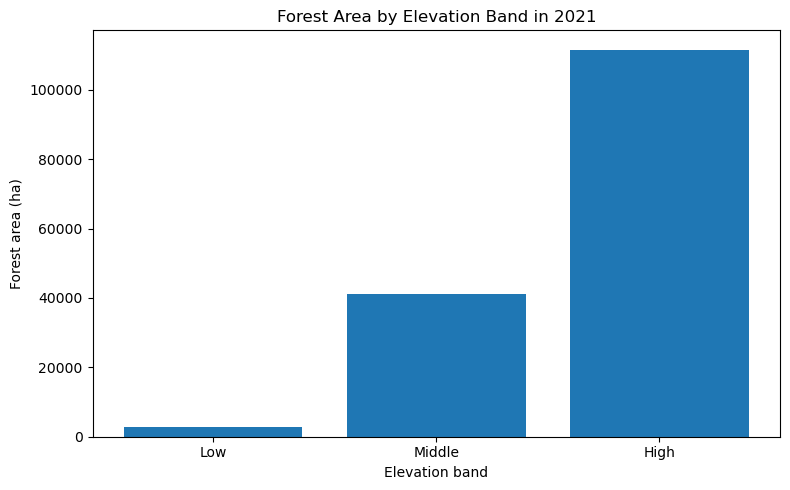

✅ Saved → figures/forest_area_by_elevation_2021.png


In [9]:
# Plot 2021 forest area by elevation band

forest_area_df = forest_area_df.sort_values('elev_low_m') # 按海拔从低到高排序

plt.figure(figsize=(8, 5))
plt.bar(
    forest_area_df['elevation_band'],
    forest_area_df['forest_area_ha']
)# 画柱状图，展示2021 年低、中、高海拔区域分别有多少森林面积

plt.xlabel('Elevation band')
plt.ylabel('Forest area (ha)')
plt.title('Forest Area by Elevation Band in 2021')
plt.tight_layout()
plt.savefig('figures/forest_area_by_elevation_2021.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Saved → figures/forest_area_by_elevation_2021.png")

In [10]:
# Compare forest area by elevation band between 2001 and 2021

def get_nlcd_year(year):
    """Load Annual NLCD land cover image for a given year."""
    return (
        annual_nlcd
        .filter(ee.Filter.eq('year', year))
        .first()
        .clip(study_area)
    ) # 加载某一年的 NLCD


def get_forest_image(nlcd_image):
    """Create a binary forest image from NLCD forest classes."""
    return (
        nlcd_image
        .remap([41, 42, 43], [1, 1, 1], 0)
        .rename('forest')
    ) # 提取森林像元。1是forest，0是non-forest


def forest_area_by_band_for_year(year, band_name, low, high): # 计算某一年、某个高程带内的森林面积
    """Calculate forest area for one year and one elevation band."""
    
    nlcd = get_nlcd_year(year)
    forest = get_forest_image(nlcd)
    elev_mask = dem.gte(low).And(dem.lt(high)) # 只保留指定高程范围内的区域
    
    forest_area = ( # 计算森林面积
        forest
        .eq(1) # 只选择森林像元
        .And(elev_mask) # 这些森林像元还必须位于指定高程带内
        .multiply(pixel_area_ha)
        .reduceRegion(# 对整个研究区内符合条件的像元面积求和
            reducer=ee.Reducer.sum(),
            geometry=study_area,
            scale=30,
            maxPixels=1e9
        )
        .get('forest')
    )
    
    return ee.Feature(None, {
        'year': year,
        'elevation_band': band_name,
        'elev_low_m': low,
        'elev_high_m': high,
        'forest_area_ha': forest_area
    })


# Define years and elevation bands
years = [2001, 2021] # 定义要比较的年份和高程带

bands = [
    ('Low', 1480, 1800),
    ('Middle', 1800, 2200),
    ('High', 2200, 3300)
]

# Build FeatureCollection
features = [] # 循环计算所有组合

for year in years:
    for band_name, low, high in bands:
        features.append(
            forest_area_by_band_for_year(year, band_name, low, high)
        )

forest_change_features = ee.FeatureCollection(features) # 6 条结果合并成一个 Earth Engine 的表格对象

# Convert to pandas DataFrame manually # 把 Earth Engine 的结果下载到 Python 本地，并转换成 pandas 表格。
features_info = forest_change_features.getInfo()['features']

rows = []
for feature in features_info:
    rows.append(feature['properties'])

forest_change_df = pd.DataFrame(rows)

forest_change_df

,elev_high_m,elev_low_m,elevation_band,forest_area_ha,year
0,1800,1480,Low,3110.104235,2001
1,2200,1800,Middle,52976.691177,2001
2,3300,2200,High,134522.167765,2001
3,1800,1480,Low,2851.566000,2021
4,2200,1800,Middle,41252.445177,2021
5,3300,2200,High,111559.856824,2021


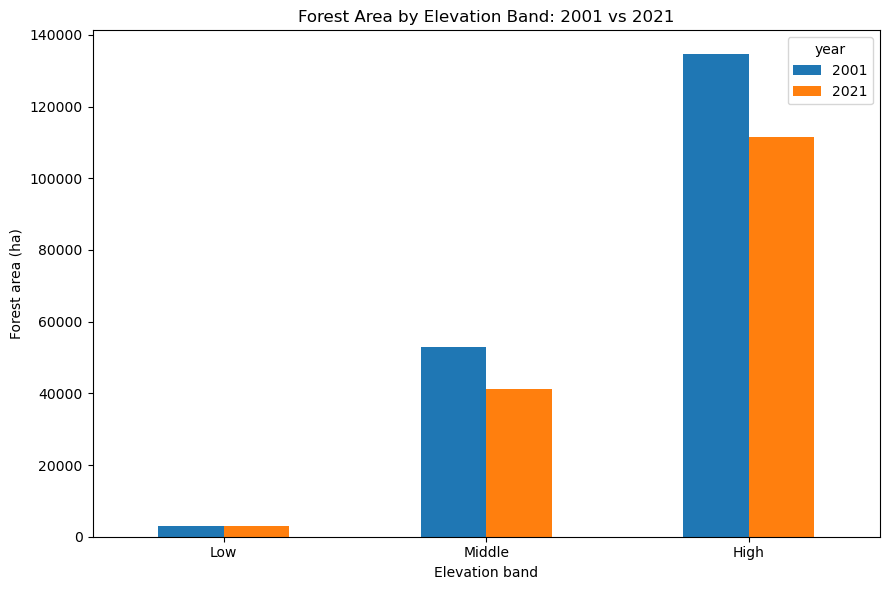

✅ Saved → figures/forest_area_by_elevation_2001_2021.png


In [11]:
# Plot forest area by elevation band for 2001 and 2021

forest_change_df = forest_change_df.sort_values(['elev_low_m', 'year'])

pivot_df = forest_change_df.pivot( # 原来的长表转换成适合画分组柱状图的宽表
    index='elevation_band',
    columns='year',
    values='forest_area_ha'
)

# Reorder elevation bands
pivot_df = pivot_df.loc[['Low', 'Middle', 'High']]

pivot_df.plot(kind='bar', figsize=(9, 6)) # 画分组柱状图

plt.xlabel('Elevation band')
plt.ylabel('Forest area (ha)')
plt.title('Forest Area by Elevation Band: 2001 vs 2021')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('figures/forest_area_by_elevation_2001_2021.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Saved → figures/forest_area_by_elevation_2001_2021.png")

In [ ]:
# How has forest cover changed across low, middle, and high elevation bands in Colorado’s Front Range from 2001 to 2021?
# The results show that forest cover is strongly concentrated at higher elevations in the Front Range study area. From 2001 to 2021, forest area declined across all elevation bands, but the largest losses occurred in the middle and high elevation bands. Low elevations contained very little forest in both years, suggesting that these areas are dominated by urban, grassland, or plains land covers rather than forest. This pattern supports analyzing forest change along the elevation gradient.

In [ ]:
### Summary of current analysis

# In this section, we defined the Front Range study area and used a DEM to confirm that the region contains a clear west-to-east elevation gradient, from higher mountainous terrain in the west to lower urban/plains areas in the east. Based on the DEM statistics, we divided the study area into low, middle, and high elevation bands. We then used Annual NLCD land cover data to calculate forest area within each elevation band for 2024, and compared forest area between 2001 and 2021.

# The results show that forest cover is strongly concentrated in the middle and high elevation bands, especially at high elevations. Forest area declined from 2001 to 2021 across all elevation bands, with the largest absolute losses occurring in the middle and high elevation zones.

# Next, we will analyze land-cover transitions, especially Forest → Developed change, to test whether forest losses at lower elevations are more closely associated with urbanization.